In [9]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

# Auto-reload makes it so if you change the .py files, the notebook updates instantly
%load_ext autoreload
%autoreload 2

from speaker_test import generate_chirp_file
from mic_test import analyze_recording
from channel_response import plot_hardware_response

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Generate the test sound

In [10]:
generate_chirp_file(output_path="../data/chirp_test.wav")

Generating chirp from 20Hz to 24000Hz over 5.0 seconds...
Success! Saved to ../data/chirp_test.wav


# Analyze setup recordings


Loaded ../data/iphone16_iphone17.wav. Sample rate: 44100 Hz


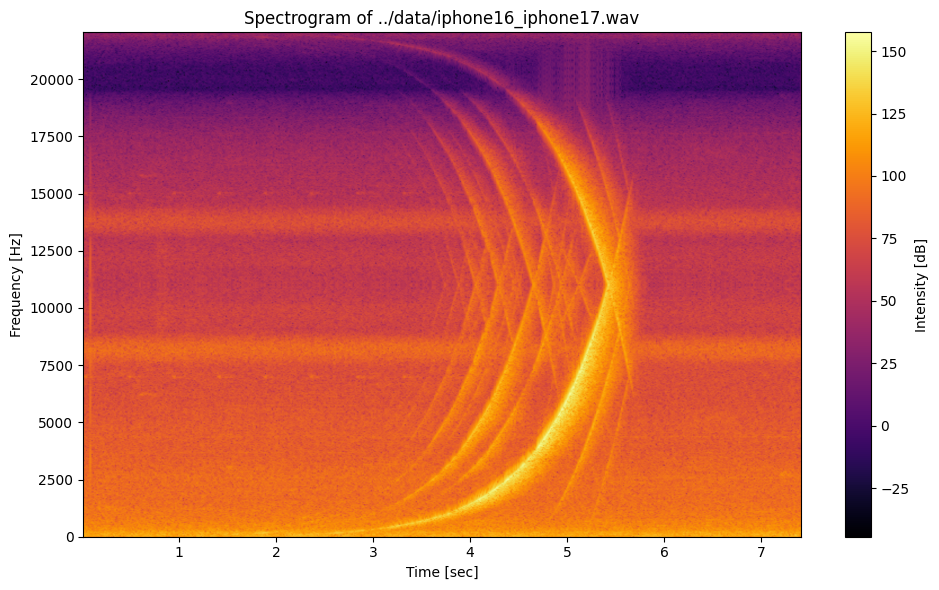

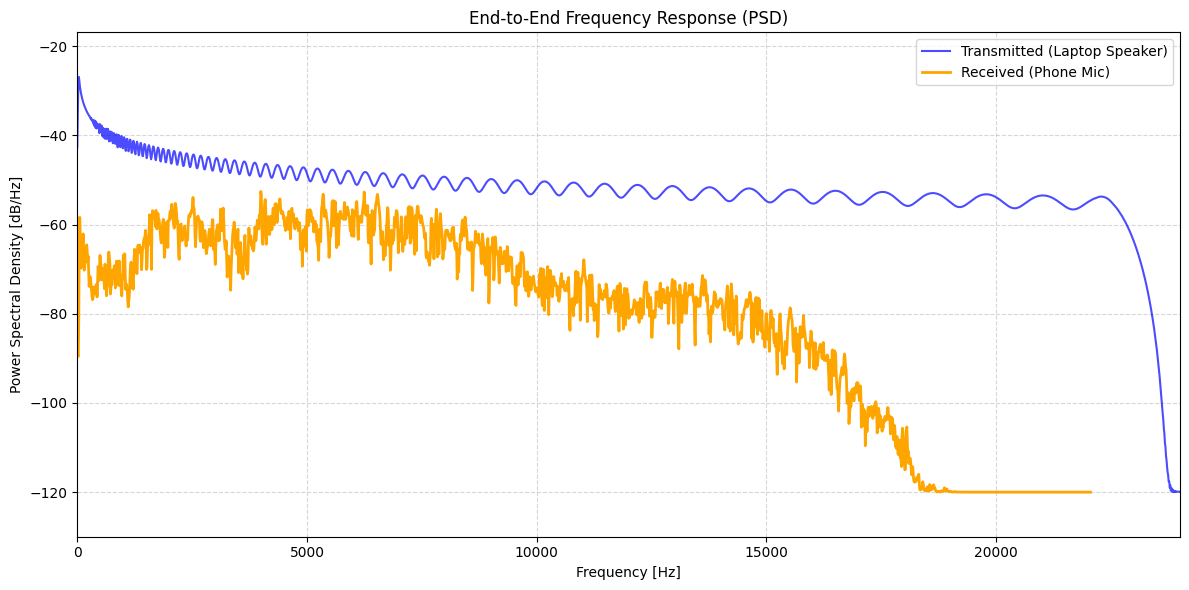

In [11]:
analyze_recording("../data/iphone16_iphone17.wav")    

plot_hardware_response('../data/chirp_test.wav', '../data/iphone16_iphone17.wav')

Loaded ../data/SLaptop_iphone17.wav. Sample rate: 44100 Hz


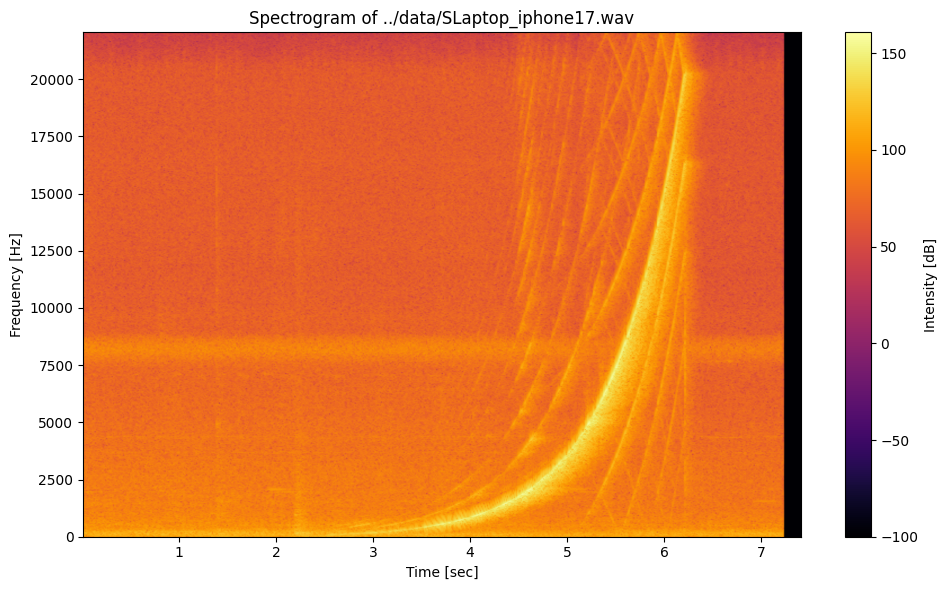

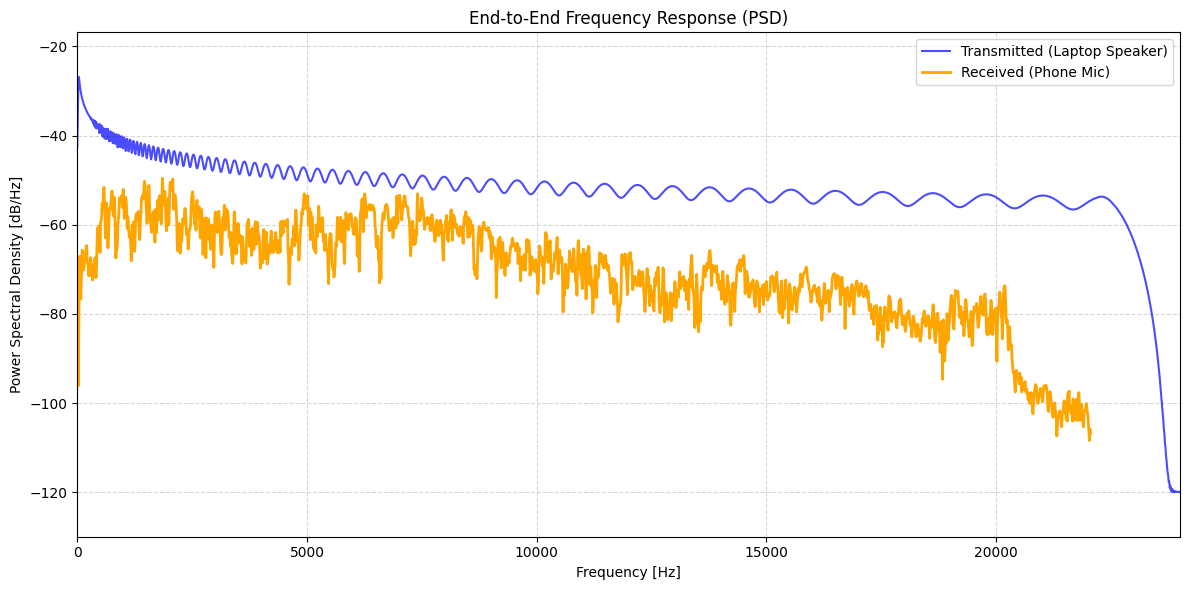

In [12]:
analyze_recording("../data/SLaptop_iphone17.wav")    

plot_hardware_response('../data/chirp_test.wav', '../data/SLaptop_iphone17.wav')

Loaded ../data/ILaptop_iphone17.wav. Sample rate: 44100 Hz


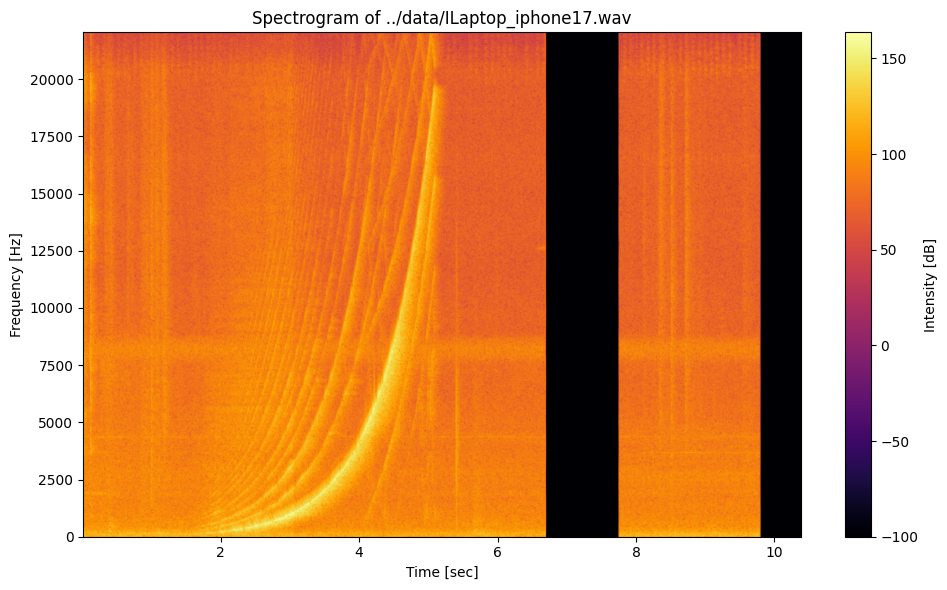

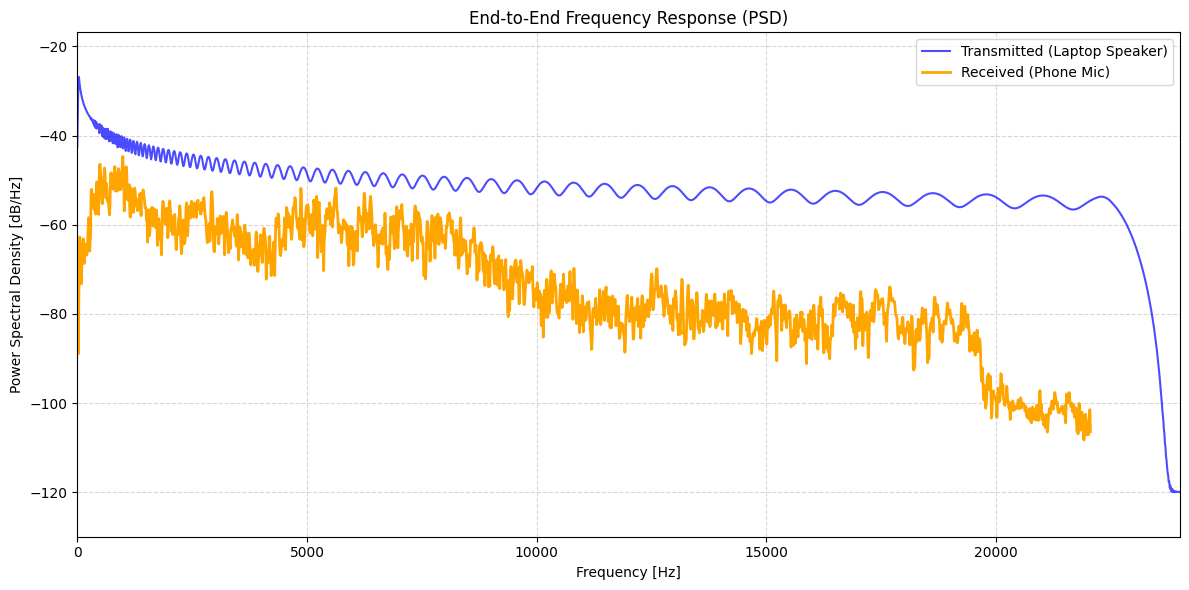

In [16]:
analyze_recording("../data/ILaptop_iphone17.wav")    

plot_hardware_response('../data/chirp_test.wav', '../data/ILaptop_iphone17.wav')

# Decide the Best Setup:

C:\Users\Ishaan\AppData\Local\Temp\ipykernel_16484\4109736492.py:26: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(path)


[Laptop I -> iPhone 17] Usable bandwidth up to ~19584 Hz
Error: Could not find ../data/ILaptop_iphone17-trim.wav. Check your spelling!
[Laptop S -> iPhone 17] Usable bandwidth up to ~20295 Hz
Error: Could not find ../data/SLaptop_iphone17-trim.wav. Check your spelling!
[iPhone 16 -> iPhone 17] Usable bandwidth up to ~15978 Hz


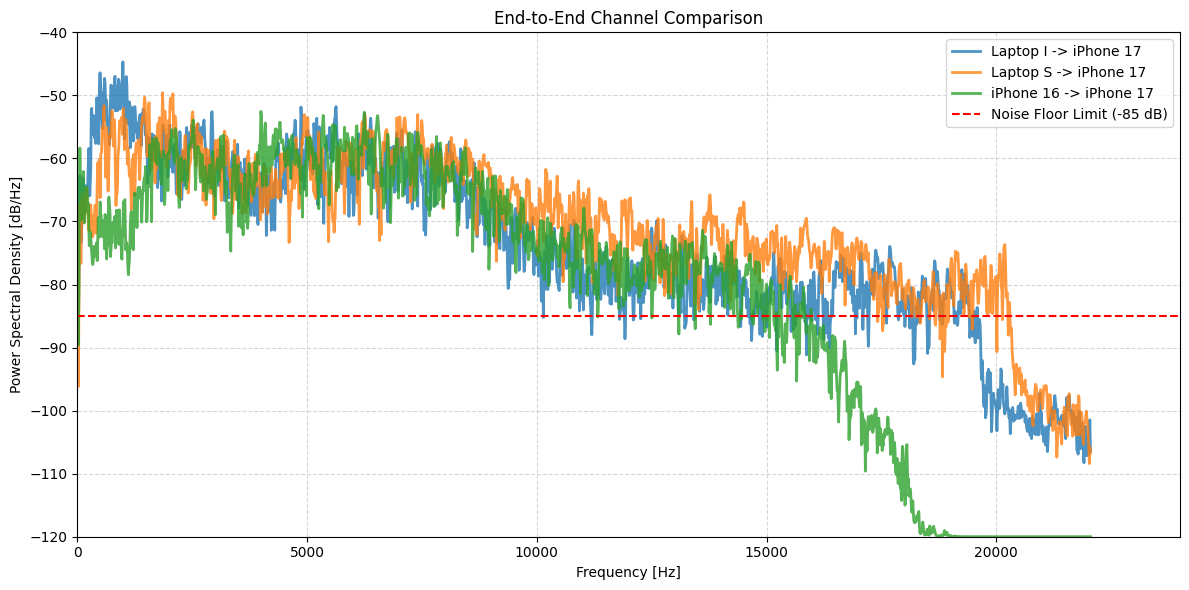

--------------------------------------------------
🏆 WINNER: Laptop S -> iPhone 17 (Cutoff: 20295 Hz)
--------------------------------------------------


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.signal import welch

# Dictionary mapping setup names to their file paths
# Assuming these are in your data folder
files = {
    "Laptop I -> iPhone 17": "../data/ILaptop_iphone17.wav",
    "Laptop I -> iPhone 17 (trimmed)": "../data/ILaptop_iphone17-trim.wav",
    "Laptop S -> iPhone 17": "../data/SLaptop_iphone17.wav",
    "Laptop S -> iPhone 17 (trimmed)": "../data/SLaptop_iphone17-trim.wav",
    "iPhone 16 -> iPhone 17": "../data/iphone16_iphone17.wav"
}

plt.figure(figsize=(12, 6))
best_setup = None
max_cutoff_freq = 0

# The dB level where we consider the signal to be "dead" (lost in noise)
# You can tweak this based on what the graph looks like
THRESHOLD_DB = -85 

for name, path in files.items():
    try:
        fs, data = wavfile.read(path)
        
        # Convert stereo to mono if necessary
        if len(data.shape) > 1: 
            data = data.mean(axis=1)
            
        # Normalize to ensure fair volume comparison
        data = data / np.max(np.abs(data))
        
        # Calculate Power Spectral Density
        f, Pxx = welch(data, fs, nperseg=4096)
        Pxx_dB = 10 * np.log10(Pxx + 1e-12)
        
        # Plot the curve
        plt.plot(f, Pxx_dB, label=name, alpha=0.8, linewidth=2)
        
        # METRIC: Find the highest frequency above 1kHz that survives the threshold
        valid_indices = np.where((f > 1000) & (Pxx_dB > THRESHOLD_DB))[0]
        
        if len(valid_indices) > 0:
            cutoff = f[valid_indices[-1]]
            print(f"[{name}] Usable bandwidth up to ~{cutoff:.0f} Hz")
            
            if cutoff > max_cutoff_freq:
                max_cutoff_freq = cutoff
                best_setup = name
        else:
             print(f"[{name}] Signal too weak to measure.")

    except FileNotFoundError:
        print(f"Error: Could not find {path}. Check your spelling!")

# Formatting the graph
plt.title('End-to-End Channel Comparison')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power Spectral Density [dB/Hz]')
plt.xlim(0, 24000)
# Set Y-axis limits based on typical acoustic recording levels
plt.ylim(-120, -40) 
plt.axhline(THRESHOLD_DB, color='red', linestyle='--', label=f'Noise Floor Limit ({THRESHOLD_DB} dB)')

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print("-" * 50)
if best_setup:
    print(f"🏆 WINNER: {best_setup} (Cutoff: {max_cutoff_freq:.0f} Hz)")
else:
    print("Could not determine a winner. Check the data.")
print("-" * 50)

# Finding SNR


C:\Users\Ishaan\AppData\Local\Temp\ipykernel_22128\1526807260.py:10: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(audio_path)


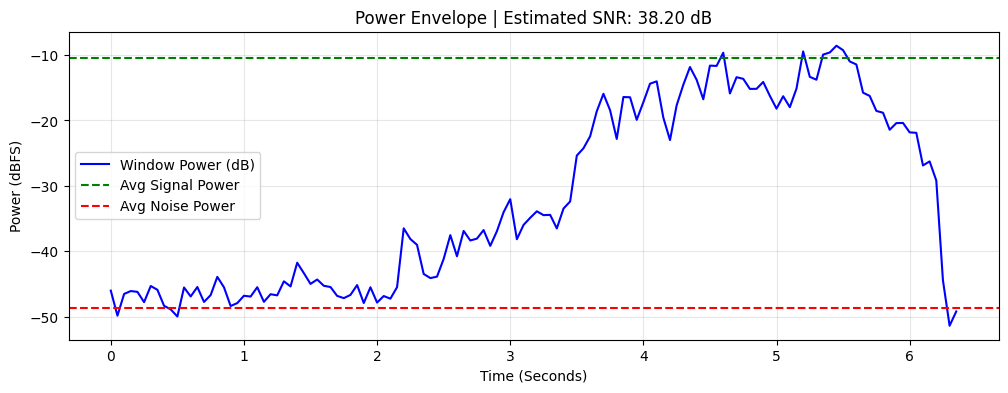

----------------------------------------
🥇 Estimated Acoustic SNR: 38.20 dB
----------------------------------------


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

def calculate_acoustic_snr(audio_path):
    """
    Estimates the Signal-to-Noise Ratio (SNR) of an acoustic recording.
    """
    # 1. Load and prepare the data
    fs, data = wavfile.read(audio_path)
    
    # Convert stereo to mono if needed
    if len(data.shape) > 1: 
        data = data.mean(axis=1)
        
    # Ignore the last second of the audio
    data = data[:-int(fs)]
        
    # Normalize the audio (-1.0 to 1.0)
    data = data / np.max(np.abs(data))
    
    # 2. Chop the audio into 50ms windows
    window_duration = 0.05 
    window_samples = int(fs * window_duration)
    num_windows = len(data) // window_samples
    
    # Calculate the average power (Amplitude^2) of each window
    window_powers = []
    for i in range(num_windows):
        window = data[i * window_samples : (i + 1) * window_samples]
        # Power = mean of squared amplitudes
        power = np.mean(window**2) 
        window_powers.append(power)
        
    window_powers = np.array(window_powers)
    
    # 3. Sort powers to separate noise from signal
    sorted_powers = np.sort(window_powers)
    
    # Assume the quietest 10% of the recording is pure background noise
    noise_power = np.mean(sorted_powers[:int(num_windows * 0.1)])
    
    # Assume the loudest 20% of the recording is the main signal peak
    signal_power = np.mean(sorted_powers[-int(num_windows * 0.1):])
    
    # 4. Calculate SNR in Decibels (dB)
    snr_db = 10 * np.log10(signal_power / noise_power)
    
    # --- Visualization ---
    plt.figure(figsize=(12, 4))
    time_axis = np.arange(num_windows) * window_duration
    plt.plot(time_axis, 10 * np.log10(window_powers + 1e-12), label="Window Power (dB)", color='blue')
    
    # Plot horizontal lines for our calculated signal and noise averages
    plt.axhline(10 * np.log10(signal_power), color='green', linestyle='--', label="Avg Signal Power")
    plt.axhline(10 * np.log10(noise_power), color='red', linestyle='--', label="Avg Noise Power")
    
    plt.title(f"Power Envelope | Estimated SNR: {snr_db:.2f} dB")
    plt.xlabel("Time (Seconds)")
    plt.ylabel("Power (dBFS)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return snr_db

# Run it on your Golden Pair
snr = calculate_acoustic_snr('../data/SLaptop_iphone17.wav')
print("-" * 40)
print(f"🥇 Estimated Acoustic SNR: {snr:.2f} dB")
print("-" * 40)